# Introduction to Transformers - AstroAI Workshop 2026

## Part 1 — Dataset Creation

> **⚠️ This notebook was run before the tutorial to build the dataset. You do not need to run it.**
> The pre-built dataset is available in the `dataset/` folder.

This notebook queries real astronomical data from the [ALeRCE broker](https://alerce.science/) and assembles two datasets:

| Dataset | Source | Classes | Objects per class |
|---------|--------|---------|------------------|
| **Image stamps** | ZTF / stamp classifier | AGN, SN, VS | ~100 (target) |
| **Light curves** | ZTF / LC classifier | SNIa, SNIbc, SNII, SLSN | ~100 (target) |

These two datasets will feed the two transformer models we build in Part 2.

---
## 1.1 — ALeRCE and the ZTF Alert Stream

[ALeRCE](https://iopscience.iop.org/article/10.3847/1538-3881/abe9bc/meta) is a Community Broker for the Vera C. Rubin Observatory and its Legacy Survey of Space and Time (LSST). It is currently processing the alert streams from LSST and the Zwicky Transient Facility (ZTF), and it aims to expand to other large etendue survey telescopes. **In this tutorial, we will use ZTF data**. ZTF scans the northern sky every few nights and generates an alert each time a brightness change is detected. ALeRCE ingests, classifies, and exposes these alerts through a public API.

Each alert carries two complementary data products:

- **Image stamps** — three 63×63 pixel cutouts: *science* (current observation), *reference* (archival baseline), and their *difference*.
- **Light curve** — the full time series of brightness measurements across ZTF bands (*g* = band 1, *r* = band 2).

ALeRCE runs two classifiers whose predictions we use as class labels:
1. **Stamp classifier** ([Carrasco-Davis et al. 2021](https://arxiv.org/abs/2008.03309)) — classifies from the *first alert only*: AGN, SN, VS, Asteroid, Bogus.
2. **Light curve classifier** ([Sánchez-Sáez et al. 2021](https://arxiv.org/abs/2008.03311)) — classifies from the *full light curve* into 15 sub-classes; we focus on the four transient ones: SNIa, SNIbc, SNII, SLSN.

We keep only high-probability classifications (≥ 0.6) to keep labels clean.

![ALeRCE taxonomy](figures/taxonomy.png)

---
## 1.2 — Setup

In [1]:
!pip install alerce scipy --quiet


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from alerce.core import Alerce
from utils import download_lc, passes_min_detections, interpolate_lc, EVAL_DATE, MIN_TIME, STEP

client = Alerce()

DATASET_DIR = Path("dataset")
DATASET_DIR.mkdir(exist_ok=True)

N_OBJECTS = 100
MIN_PROB  = 0.7

---
## 1.3 — Image Stamp Dataset

For each object we download the 21×21 px triplet (science, reference, difference) from its **first detection** and stack it into a tensor of shape **(3, 21, 21)** — the format the Vision Transformer will expect.

![Stamp examples](figures/class_samples.png)

In [3]:
STAMP_CLASSES = ["AGN", "SN", "VS"]
STAMP_SIZE    = 63  # expected cutout side length in pixels


def download_stamp(oid: str) -> np.ndarray | None:
    """Return first-detection stamp as float32 (3, 63, 63), or None on failure.

    Skips stamps whose cutout size differs from STAMP_SIZE (older ZTF alerts
    occasionally return different dimensions).
    """
    try:
        det = client.query_detections(oid, format="pandas").sort_values("mjd")
        candid = det.loc[det["has_stamp"]].iloc[0]["candid"]
        raw = client.get_stamps(oid, candid)
        planes = [raw[0].data, raw[1].data, raw[2].data]
        if any(p.shape != (STAMP_SIZE, STAMP_SIZE) for p in planes):
            return None
        return np.stack(planes, axis=0).astype(np.float32)
    except Exception as exc:
        print(f"    [SKIP] {oid}: {exc}")
        return None


stamps_list, stamp_labels, stamp_oids = [], [], []

for label_idx, cl in enumerate(STAMP_CLASSES):
    objects = client.query_objects(
        classifier="stamp_classifier", class_name=cl,
        probability=MIN_PROB, ranking=1,
        order_by="probability", order_mode="DESC",
        count=False, page_size=N_OBJECTS, format="pandas",
    ).set_index("oid")
    print(f"{cl}: {len(objects)} objects queried")
    for oid in objects.index:
        stamp = download_stamp(oid)
        if stamp is not None:
            stamps_list.append(stamp)
            stamp_labels.append(label_idx)
            stamp_oids.append(oid)

stamps_array = np.stack(stamps_list)    # (N, 3, 63, 63)
stamp_labels = np.array(stamp_labels)   # (N,)
print(f"\nStamps: {stamps_array.shape}")
print("Per class:", {cl: int((stamp_labels == i).sum()) for i, cl in enumerate(STAMP_CLASSES)})

AGN: 100 objects queried


SN: 100 objects queried
VS: 100 objects queried
    [SKIP] ZTF18aaxfcmb: Not a gzipped file (b'{"')
    [SKIP] ZTF18aagzkvt: Not a gzipped file (b'<h')
    [SKIP] ZTF22aahtyiv: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}
    [SKIP] ZTF18acidohz: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}
    [SKIP] ZTF18abcgthj: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}
    [SKIP] ZTF18absubim: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}
    [SKIP] ZTF17aadihgk: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}
    [SKIP] ZTF18abyplqa: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}
    [SKIP] ZTF18abuyhrm: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}
    [SKIP] ZTF26aaqzuvf: {'Error code': 403, 'Message': 'Unknown API error.', 'Data': 'Unkno

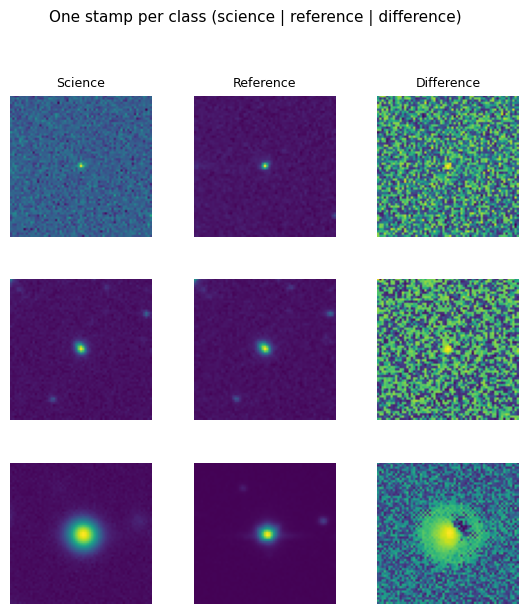

In [4]:
fig, axes = plt.subplots(len(STAMP_CLASSES), 3, figsize=(7, len(STAMP_CLASSES) * 2.2),
                         gridspec_kw={"wspace": 0.05, "hspace": 0.3})
for row, cl in enumerate(STAMP_CLASSES):
    idx = np.where(stamp_labels == row)[0][0]
    for col, title in enumerate(["Science", "Reference", "Difference"]):
        ax = axes[row, col]
        ax.imshow(np.arcsinh(stamps_array[idx, col]), cmap="viridis", origin="lower")
        ax.axis("off")
        if row == 0: ax.set_title(title, fontsize=9)
        if col == 0: ax.set_ylabel(cl, fontsize=9, rotation=0, labelpad=40, va="center")
fig.suptitle("One stamp per class (science | reference | difference)", fontsize=11, y=1.01)
plt.savefig(DATASET_DIR / "stamp_examples.png", bbox_inches="tight", dpi=120)
plt.show()

In [5]:
np.savez(DATASET_DIR / "stamps.npz",
    stamps=stamps_array,
    labels=stamp_labels,
    oids=np.array(stamp_oids),
    class_names=np.array(STAMP_CLASSES),
)
print("Saved:", DATASET_DIR / "stamps.npz")

Saved: dataset/stamps.npz


---
## 1.4 — Light Curve Dataset

### Preprocessing strategy

Raw ZTF light curves are **irregularly sampled**: observations happen when the telescope can observe and weather permits. To remove this complexity from the transformer, we interpolate onto a regular grid following [Pérez-Carrasco et al. 2023](https://iopscience.iop.org/article/10.3847/1538-3881/ace0c1):

- Time is expressed relative to each object's **first detection** (`dt = mjd − first_mjd`)
- **Non-detections** before the trigger are prepended to anchor the pre-explosion baseline
- Linear interpolation maps each band onto a **regular 3-day grid** from −30 to +150 days
- Unobserved steps are filled with 0 and flagged by a **binary mask**

The result is a fixed-length tensor of shape **(T=60, 2)** per object — 60 time steps × 2 bands — plus a mask of the same shape. Implementation is in `utils/lc_preprocessing.py`. We keep only objects with ≥10 detections per band.

In [11]:
LC_CLASSES       = ["SNIa", "SNIbc", "SNII", "SLSN"]
MIN_DET_PER_BAND = 10
label_map        = {cl: i for i, cl in enumerate(LC_CLASSES)}
MIN_PROB  = 0.6

lc_fluxes, lc_masks, lc_labels, lc_oids = [], [], [], []
times = None  # shared time axis, same for every object

for cl in LC_CLASSES:
    # Note: lc_classifier does not support probability/ranking as query filters.
    # We request more objects and filter by probability post-query.
    objects = client.query_objects(
        classifier="lc_classifier", class_name=cl,
        order_by="probability", order_mode="DESC",
        page_size=N_OBJECTS * 2, format="pandas",
    )
    objects = objects[objects["probability"] >= MIN_PROB].head(N_OBJECTS).set_index("oid")
    print(f"{cl}: {len(objects)} objects queried")

    for oid in objects.index:
        det, nondet = download_lc(oid, client)
        if det is None or not passes_min_detections(det, MIN_DET_PER_BAND):
            continue
        fluxes, masks, times = interpolate_lc(det, nondet)
        lc_fluxes.append(fluxes)
        lc_masks.append(masks)
        lc_labels.append(label_map[cl])
        lc_oids.append(oid)

lc_fluxes = np.stack(lc_fluxes)   # (N, T, 2)
lc_masks  = np.stack(lc_masks)    # (N, T, 2)
lc_labels = np.array(lc_labels)   # (N,)
print(f"\nLight curves: {lc_fluxes.shape}  — T={times.shape[0]} steps")
print("Per class:", {cl: int((lc_labels == i).sum()) for i, cl in enumerate(LC_CLASSES)})

SNIa: 100 objects queried


/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


SNIbc: 57 objects queried
SNII: 98 objects queried


/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504

SLSN: 100 objects queried


/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/maperezc/Documents/l1_plume_detection/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo



Light curves: (310, 60, 2)  — T=60 steps
Per class: {'SNIa': 91, 'SNIbc': 29, 'SNII': 98, 'SLSN': 92}


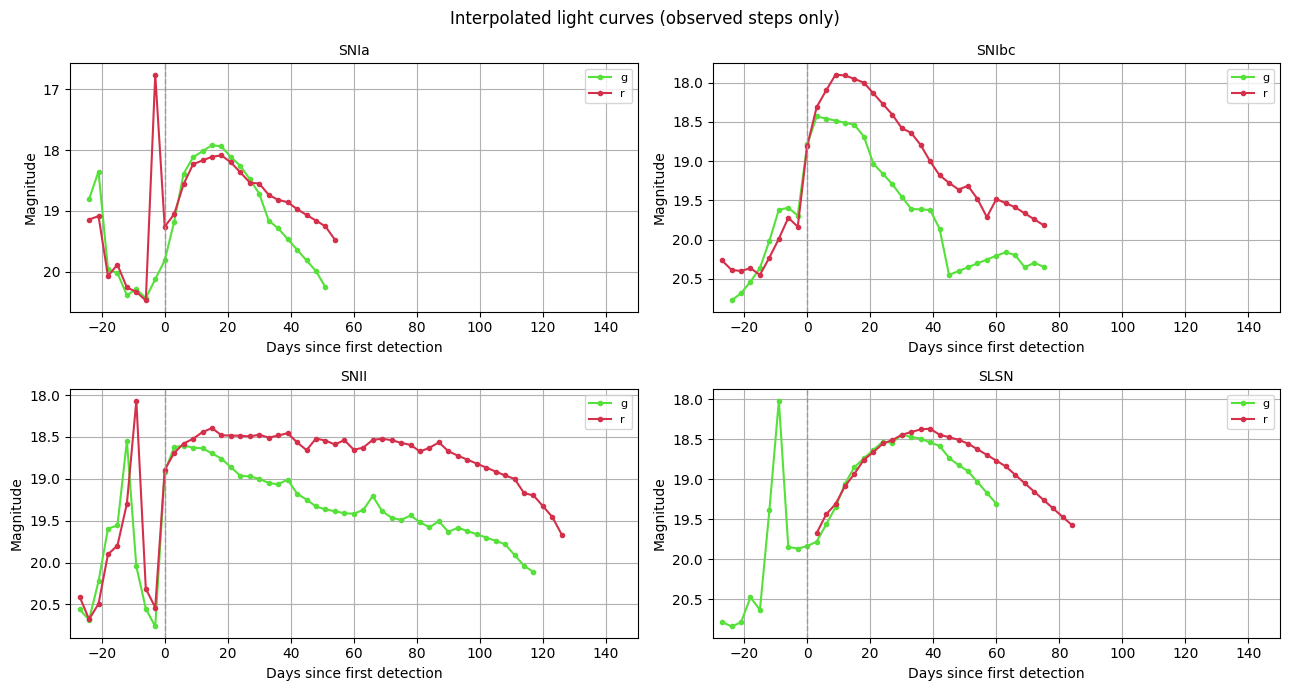

In [41]:
COLORS      = {0: "#56E03A", 1: "#D42F4B"}
BAND_LABELS = {0: "g", 1: "r"}

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, (cl, label_idx) in zip(axes.flatten(), label_map.items()):
    idx = np.where(lc_labels == label_idx)[0][0]
    for b in range(2):
        observed = lc_masks[idx, :, b] == 1
        ax.plot(times[observed], lc_fluxes[idx, observed, b], "o-",
                ms=3, color=COLORS[b], label=BAND_LABELS[b])
    ax.axvline(0, color="0.6", ls="--", lw=1)   # optional: marks first detection
    ax.invert_yaxis()
    ax.set_title(cl, fontsize=10)
    ax.set_xlabel("Days since first detection")
    ax.set_ylabel("Magnitude")
    ax.set_xlim(-30, 150)
    ax.legend(fontsize=8)
    ax.grid()
fig.suptitle("Interpolated light curves (observed steps only)", fontsize=12)
plt.tight_layout()
plt.savefig(DATASET_DIR / "lc_examples.png", dpi=120)
plt.show()

In [13]:
np.savez(DATASET_DIR / "lightcurves.npz",
    fluxes=lc_fluxes,
    masks=lc_masks,
    labels=lc_labels,
    oids=np.array(lc_oids),
    times=times,
    class_names=np.array(LC_CLASSES),
)
print("Saved:", DATASET_DIR / "lightcurves.npz")

Saved: dataset/lightcurves.npz


---
## 1.5 — Dataset Summary

In [14]:
stamps = np.load(DATASET_DIR / "stamps.npz",      allow_pickle=True)
lcs    = np.load(DATASET_DIR / "lightcurves.npz", allow_pickle=True)

print("=== Stamp dataset ===")
print(f"  shape   : {stamps['stamps'].shape}   # (N, channels, H, W)")
print(f"  classes : {list(stamps['class_names'])}")
print(f"  counts  : { {cl: int((stamps['labels']==i).sum()) for i, cl in enumerate(stamps['class_names'])} }")

print()
print("=== Light curve dataset ===")
print(f"  shape   : {lcs['fluxes'].shape}   # (N, T, bands)")
print(f"  window  : {MIN_TIME} to +{EVAL_DATE} days, step={STEP} days → T={lcs['times'].shape[0]}")
print(f"  classes : {list(lcs['class_names'])}")
print(f"  counts  : { {cl: int((lcs['labels']==i).sum()) for i, cl in enumerate(lcs['class_names'])} }")

=== Stamp dataset ===
  shape   : (286, 3, 63, 63)   # (N, channels, H, W)
  classes : ['AGN', 'SN', 'VS']
  counts  : {'AGN': 100, 'SN': 99, 'VS': 87}

=== Light curve dataset ===
  shape   : (310, 60, 2)   # (N, T, bands)
  window  : -30 to +150 days, step=3 days → T=60
  classes : ['SNIa', 'SNIbc', 'SNII', 'SLSN']
  counts  : {'SNIa': 91, 'SNIbc': 29, 'SNII': 98, 'SLSN': 92}


# Part 2 — Transformers for Astronomical Data

In this notebook we build two transformer models from scratch and train them on the ALeRCE dataset:

| Model | Input | Task |
|-------|-------|------|
| **Sequence Transformer** | Light curves `(T=60, 2 bands)` | Classify SNIa / SNIbc / SNII / SLSN |
| **Vision Transformer (ViT)** | Image stamps `(3, 63, 63)` | Classify AGN / SN / VS |

---
## 2.1 — Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn

from utils.data     import make_lc_loaders, make_stamp_loaders
from utils.training import fit, plot_history, get_predictions, plot_confusion_matrix

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Part 2 is self-contained: define the dataset path here so this part
# runs without executing the (pre-run) dataset-creation cells in Part 1.
DATASET_DIR = Path("dataset")


Device: cpu


In [2]:
lc_train, lc_val, lc_test, LC_CLASSES = make_lc_loaders(
    DATASET_DIR / "lightcurves.npz", val_frac=0.15, test_frac=0.15, batch_size=32
)
st_train, st_val, st_test, ST_CLASSES = make_stamp_loaders(
    DATASET_DIR / "stamps.npz",      val_frac=0.15, test_frac=0.15, batch_size=32
)

x_lc, _ = next(iter(lc_train))
x_st, _ = next(iter(st_train))
print(f"LC batch shape   : {tuple(x_lc.shape)}  →  (batch, T, features)")
print(f"Stamp batch shape: {tuple(x_st.shape)}  →  (batch, channels, H, W)")
print(f"LC classes  : {LC_CLASSES}")
print(f"Stamp classes: {ST_CLASSES}")

LC batch shape   : (32, 60, 4)  →  (batch, T, features)
Stamp batch shape: (32, 3, 63, 63)  →  (batch, channels, H, W)
LC classes  : ['SNIa', 'SNIbc', 'SNII', 'SLSN']
Stamp classes: ['AGN', 'SN', 'VS']


---
## 2.2 — The Transformer Architecture

### Why transformers for astronomy?

Recurrent networks (RNNs, LSTMs) process sequences **step by step** — to relate an observation at day 100 to one at day 10, information must propagate through 90 hidden states. This creates a bottleneck for long-range dependencies and prevents parallelism during training.

Transformers replace recurrence with **self-attention**: every element in the sequence directly attends to every other element. A brightness measurement at day 100 can attend to the peak at day 10 in a single operation. This is natural for light curves (where classification depends on features like rise time, peak, and plateau that can be far apart) and for image stamps (where the source position relative to the host galaxy matters globally).

---

### Scaled Dot-Product Attention

Given a sequence of $T$ tokens, each a $d$-dimensional vector, we project to three matrices:

$$Q = XW_Q, \quad K = XW_K, \quad V = XW_V$$

The attention output is:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

- $QK^\top$ produces a $(T \times T)$ matrix of **compatibility scores** — how much should token $i$ attend to token $j$?
- The softmax normalises these into **attention weights** that sum to 1.
- The output is a weighted sum of the **values** $V$.
- The $\sqrt{d_k}$ scaling prevents the dot products from growing large, which would push the softmax into saturation and kill gradients.

**Multi-head attention** runs $H$ independent attention operations in parallel, each in a $d/H$-dimensional subspace. The outputs are concatenated and projected back:

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_H)\, W_O$$

Each head can learn to focus on a different aspect — one head might track the rise of the light curve, another the colour evolution across bands.

---

### Encoder Block

Each encoder block applies two sub-layers, each with a residual connection:

```
x  →  LayerNorm  →  MultiHeadAttention  →  + x
   →  LayerNorm  →  Feed-Forward (MLP)  →  + x
```

We use **Pre-LayerNorm** (normalise before each sub-layer), which is more stable than the original post-norm formulation.

---

### The [CLS] Token

Attention produces one output vector per input token — but classification needs a single fixed-size representation. The solution: **prepend a learnable [CLS] token** to the sequence. Through attention it learns to aggregate information from all other tokens. After the transformer, only the [CLS] output is fed to the classification head.

```
Input:   [CLS]  t₁  t₂  ...  tT
Output:  [CLS]' t₁' t₂' ...  tT'   ←  use only [CLS]' for classification
```

---
## 2.3 — Building Blocks

In [3]:
class MultiHeadAttention(nn.Module):
    """Scaled dot-product multi-head self-attention."""

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.scale   = self.d_head ** -0.5
        self.qkv     = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj    = nn.Linear(d_model, d_model)
        self.drop    = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        B, T, _ = x.shape

        # Project once to Q, K, V for all heads
        qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.d_head)
        qkv = qkv.permute(2, 0, 3, 1, 4)        # (3, B, H, T, d_head)
        q, k, v = qkv.unbind(0)                  # each (B, H, T, d_head)

        # Attention weights: softmax(QKᵀ / √d_k)
        scores = (q @ k.transpose(-2, -1)) * self.scale   # (B, H, T, T)
        attn   = self.drop(scores.softmax(dim=-1))         # (B, H, T, T)

        # Weighted sum of values, then merge heads
        out = (attn @ v).transpose(1, 2).reshape(B, T, -1)  # (B, T, d_model)
        return self.proj(out), attn                          # return weights for visualization

In [4]:
class TransformerBlock(nn.Module):
    """Pre-LayerNorm Transformer encoder block (attention + FFN + residuals)."""

    def __init__(self, d_model: int, n_heads: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn  = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.GELU(),
            nn.Linear(ff_dim, d_model), nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        attn_out, attn_w = self.attn(self.norm1(x))
        x = x + attn_out               # residual
        x = x + self.ff(self.norm2(x)) # residual
        return x, attn_w

---
## 2.4 — Sequence Transformer for Light Curve Classification

Each light curve sample is a tensor of shape `(T=60, 4)`: interpolated magnitudes for g and r bands plus their binary observation masks. The architecture is:

```
(B, T, 4)  →  Linear embedding  →  (B, T, d_model)
           →  prepend [CLS]     →  (B, T+1, d_model)
           →  + positional emb. →  (B, T+1, d_model)
           →  N × TransformerBlock
           →  [CLS] output      →  Linear head  →  (B, n_classes)
```

In [5]:
class LCTransformer(nn.Module):
    """Transformer encoder for multi-band light curve classification."""

    def __init__(self, n_features: int, seq_len: int, d_model: int, n_heads: int,
                 ff_dim: int, n_layers: int, n_classes: int, dropout: float = 0.1):
        super().__init__()
        self.embedding = nn.Linear(n_features, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len + 1, d_model) * 0.02)
        self.blocks    = nn.ModuleList([
            TransformerBlock(d_model, n_heads, ff_dim, dropout) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        B = x.shape[0]
        x = self.embedding(x)                                # (B, T, d_model)
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim=1)  # prepend [CLS]
        x = x + self.pos_embed
        attn_list = []
        for block in self.blocks:
            x, attn = block(x)
            attn_list.append(attn)
        x = self.norm(x)
        logits = self.head(x[:, 0])  # [CLS] token → classification head
        return (logits, attn_list) if return_attn else logits

In [6]:
# Hyperparameters
T          = x_lc.shape[1]   # 60 time steps
N_FEATURES = x_lc.shape[2]   # 4  (g-flux, r-flux, g-mask, r-mask)

lc_model = LCTransformer(
    n_features=N_FEATURES, seq_len=T,
    d_model=64, n_heads=4, ff_dim=128, n_layers=2,
    n_classes=len(LC_CLASSES), dropout=0.1,
).to(device)

n_params = sum(p.numel() for p in lc_model.parameters())
print(f"LCTransformer  —  {n_params:,} parameters")

LCTransformer  —  71,236 parameters


In [7]:
lc_history = fit(lc_model, lc_train, lc_val, n_epochs=60, lr=1e-3, device=device, print_every=10)

  [ 10/60]  train  loss 0.238  acc 92.19%  |  val  loss 0.313  acc 89.36%
  [ 20/60]  train  loss 0.159  acc 94.27%  |  val  loss 0.480  acc 87.23%
  [ 30/60]  train  loss 0.087  acc 97.92%  |  val  loss 0.314  acc 89.36%
  [ 40/60]  train  loss 0.014  acc 100.00%  |  val  loss 0.251  acc 91.49%
  [ 50/60]  train  loss 0.033  acc 99.48%  |  val  loss 0.226  acc 93.62%
  [ 60/60]  train  loss 0.013  acc 99.48%  |  val  loss 0.217  acc 93.62%


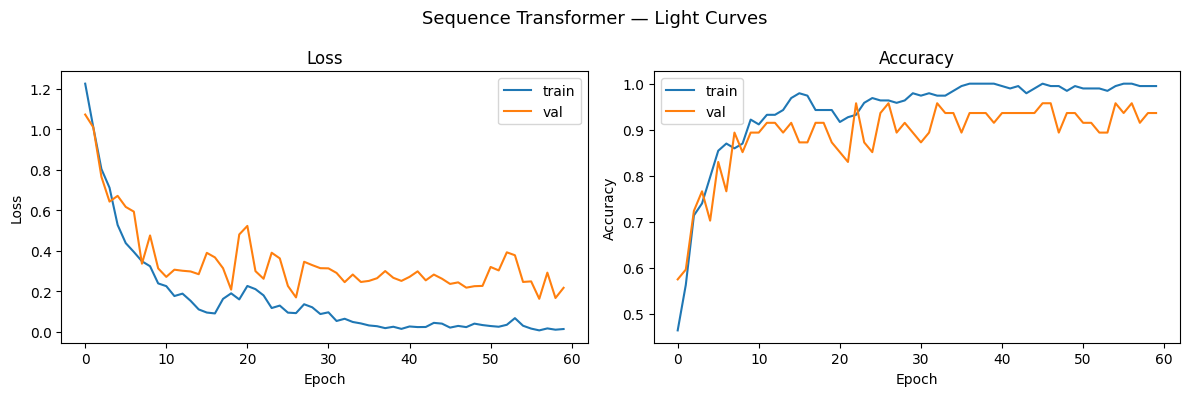

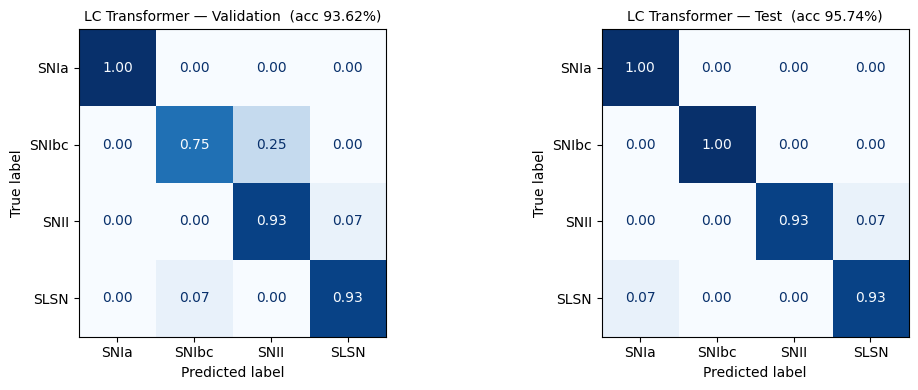

In [8]:
plot_history(lc_history, title="Sequence Transformer — Light Curves")

preds_val,  labels_val  = get_predictions(lc_model, lc_val,  device)
preds_test, labels_test = get_predictions(lc_model, lc_test, device)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
from utils.training import plot_confusion_matrix as _cm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for ax, (preds, labels, split) in zip(axes, [
    (preds_val,  labels_val,  "Validation"),
    (preds_test, labels_test, "Test"),
]):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import numpy as np
    cm = confusion_matrix(labels, preds, normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=LC_CLASSES).plot(
        ax=ax, colorbar=False, cmap="Blues", values_format=".2f"
    )
    val_acc = (preds == labels).mean()
    ax.set_title(f"LC Transformer — {split}  (acc {val_acc:.2%})", fontsize=10)
plt.tight_layout()
plt.show()

### Attention Visualization

We can inspect **what the [CLS] token attends to** in the last transformer layer. High attention weight at time step $t$ means that time step was important for classifying this object.

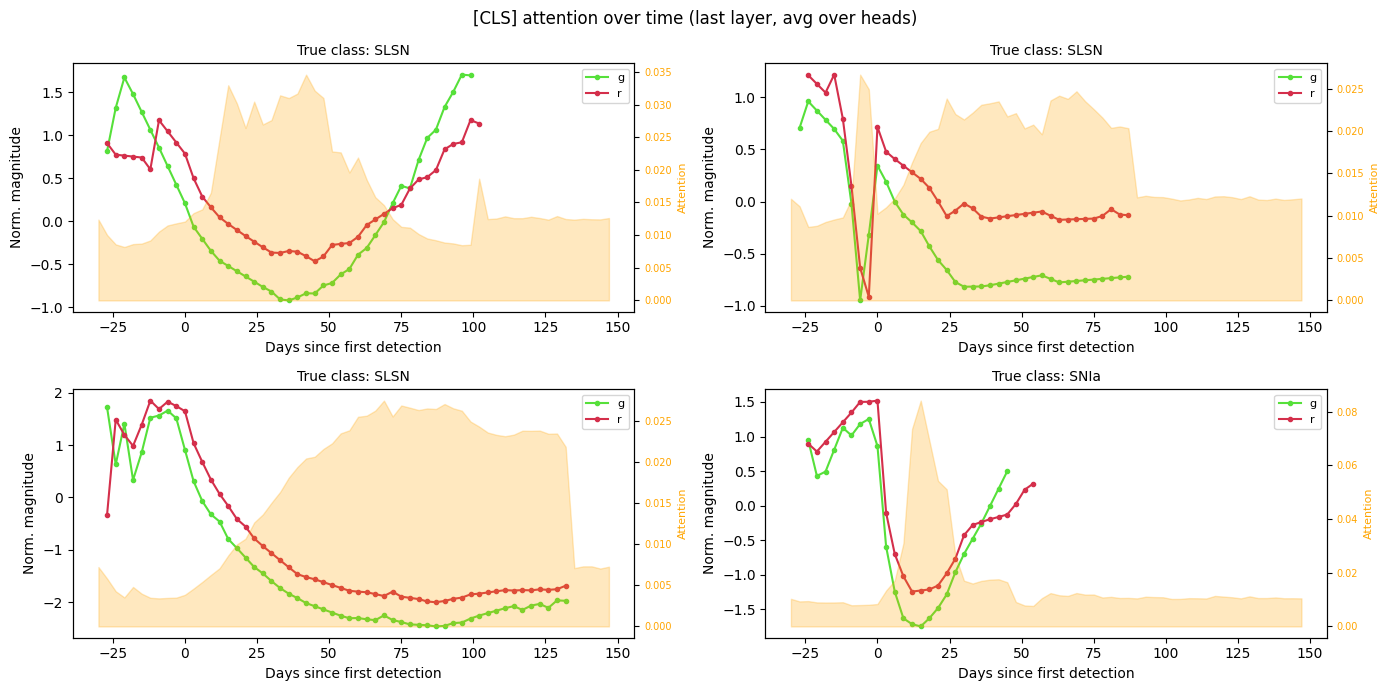

In [9]:
lc_model.eval()
x_batch, y_batch = next(iter(lc_val))

with torch.no_grad():
    _, attn_list = lc_model(x_batch.to(device), return_attn=True)

# Last-layer attention from [CLS] (position 0) to all time steps; average over heads
cls_attn = attn_list[-1][:, :, 0, 1:].mean(dim=1).cpu().numpy()  # (B, T)

COLORS = {0: "#56E03A", 1: "#D42F4B"}
BANDS  = {0: "g", 1: "r"}
times  = np.load(DATASET_DIR / "lightcurves.npz", allow_pickle=True)["times"]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, i in zip(axes.flatten(), range(4)):
    x_np = x_batch[i].numpy()          # (T, 4): [g-flux, r-flux, g-mask, r-mask]
    ax2  = ax.twinx()
    for b in range(2):
        obs = x_np[:, b + 2] == 1      # mask channel
        if obs.any():
            ax.plot(times[obs], x_np[obs, b], "o-", ms=3, color=COLORS[b], label=BANDS[b])
    ax2.fill_between(times, cls_attn[i], alpha=0.25, color="orange")
    ax2.set_ylabel("Attention", color="orange", fontsize=8)
    ax2.tick_params(axis="y", labelcolor="orange", labelsize=7)
    ax.set_title(f"True class: {LC_CLASSES[y_batch[i]]}", fontsize=10)
    ax.set_xlabel("Days since first detection")
    ax.set_ylabel("Norm. magnitude")
    ax.legend(fontsize=8)

fig.suptitle("[CLS] attention over time (last layer, avg over heads)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 2.5 — Vision Transformer (ViT) for Stamp Classification

The ViT idea ([Dosovitskiy et al. 2020](https://arxiv.org/abs/2010.11929)): split the image into fixed-size **patches**, flatten each into a vector, project to $d_{\text{model}}$, and treat the resulting sequence exactly like tokens in a language transformer.

For our 63×63 stamps with patch size 9:

$$\text{patches} = \left(\frac{63}{9}\right)^2 = 49, \quad \text{each patch} = 9 \times 9 \times 3 = 243 \text{ features}$$

```
(B, 3, 63, 63)  →  Conv2d(patch_size=9)  →  (B, 49, d_model)    # patch embedding
               →  prepend [CLS]          →  (B, 50, d_model)
               →  + positional emb.      →  (B, 50, d_model)
               →  N × TransformerBlock
               →  [CLS] output → Linear head → (B, n_classes)
```

The **same `TransformerBlock`** we defined above is reused here — ViT and the sequence transformer share identical internal blocks. Only the input embedding differs.

In [10]:
class PatchEmbedding(nn.Module):
    """Split image into patches and project each to d_model.

    A Conv2d with kernel_size=stride=patch_size is equivalent to applying
    the same linear projection independently to each non-overlapping patch.
    """
    def __init__(self, img_size: int, patch_size: int, in_channels: int, d_model: int):
        super().__init__()
        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, d_model, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """(B, C, H, W) → (B, N_patches, d_model)"""
        return self.proj(x).flatten(2).transpose(1, 2)


class ViT(nn.Module):
    """Vision Transformer for image stamp classification."""

    def __init__(self, img_size: int, patch_size: int, in_channels: int,
                 d_model: int, n_heads: int, ff_dim: int, n_layers: int,
                 n_classes: int, dropout: float = 0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, d_model)
        n_patches        = (img_size // patch_size) ** 2
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed   = nn.Parameter(torch.randn(1, n_patches + 1, d_model) * 0.02)
        self.blocks      = nn.ModuleList([
            TransformerBlock(d_model, n_heads, ff_dim, dropout) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        B = x.shape[0]
        x = self.patch_embed(x)                               # (B, N, d_model)
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim=1)  # prepend [CLS]
        x = x + self.pos_embed
        attn_list = []
        for block in self.blocks:
            x, attn = block(x)
            attn_list.append(attn)
        x = self.norm(x)
        logits = self.head(x[:, 0])  # [CLS] token → classification head
        return (logits, attn_list) if return_attn else logits

In [11]:
IMG_SIZE   = x_st.shape[-1]   # 63
PATCH_SIZE = 9                 # → 7×7 = 49 patches

vit_model = ViT(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=3,
    d_model=64, n_heads=4, ff_dim=128, n_layers=2,
    n_classes=len(ST_CLASSES), dropout=0.1,
).to(device)

n_params = sum(p.numel() for p in vit_model.parameters())
print(f"ViT  —  {n_params:,} parameters")
print(f"      patches: {vit_model.patch_embed.n_patches}  ({IMG_SIZE//PATCH_SIZE}×{IMG_SIZE//PATCH_SIZE} grid)") 

ViT  —  85,763 parameters
      patches: 49  (7×7 grid)


In [12]:
vit_history = fit(vit_model, st_train, st_val, n_epochs=60, lr=1e-3, device=device, print_every=10)

  [ 10/60]  train  loss 0.351  acc 82.29%  |  val  loss 0.934  acc 62.79%
  [ 20/60]  train  loss 0.070  acc 97.92%  |  val  loss 1.594  acc 58.14%
  [ 30/60]  train  loss 0.160  acc 94.27%  |  val  loss 1.626  acc 60.47%
  [ 40/60]  train  loss 0.081  acc 97.92%  |  val  loss 1.524  acc 60.47%
  [ 50/60]  train  loss 0.007  acc 100.00%  |  val  loss 2.026  acc 60.47%
  [ 60/60]  train  loss 0.040  acc 98.44%  |  val  loss 2.097  acc 58.14%


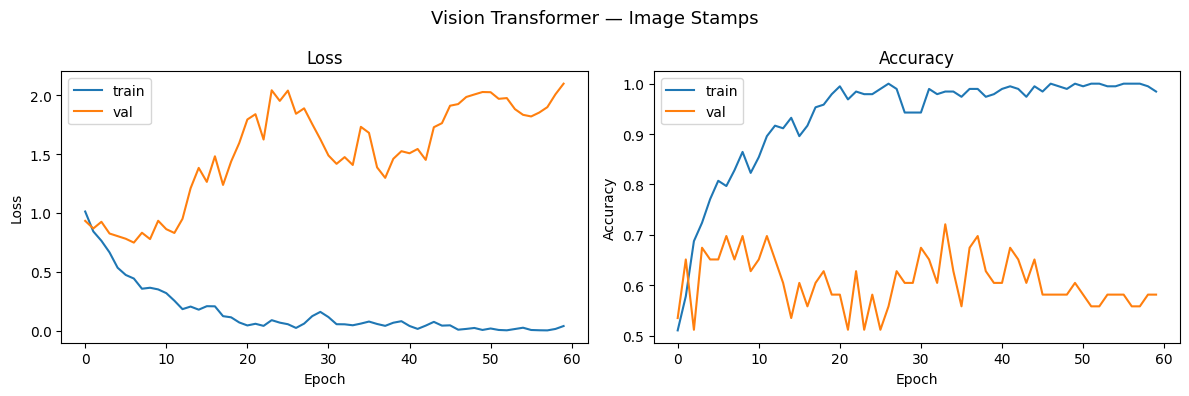

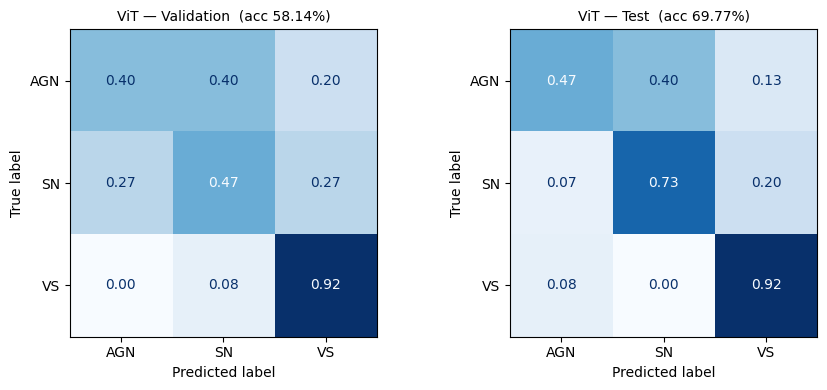

In [13]:
plot_history(vit_history, title="Vision Transformer — Image Stamps")

preds_val,  labels_val  = get_predictions(vit_model, st_val,  device)
preds_test, labels_test = get_predictions(vit_model, st_test, device)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (preds, labels, split) in zip(axes, [
    (preds_val,  labels_val,  "Validation"),
    (preds_test, labels_test, "Test"),
]):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    cm = confusion_matrix(labels, preds, normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=ST_CLASSES).plot(
        ax=ax, colorbar=False, cmap="Blues", values_format=".2f"
    )
    acc = (preds == labels).mean()
    ax.set_title(f"ViT — {split}  (acc {acc:.2%})", fontsize=10)
plt.tight_layout()
plt.show()

### Attention Map Visualization

We reshape the [CLS] → patch attention weights back to the 7×7 patch grid and overlay it on the original stamp. Bright regions are the patches the model relied on most.

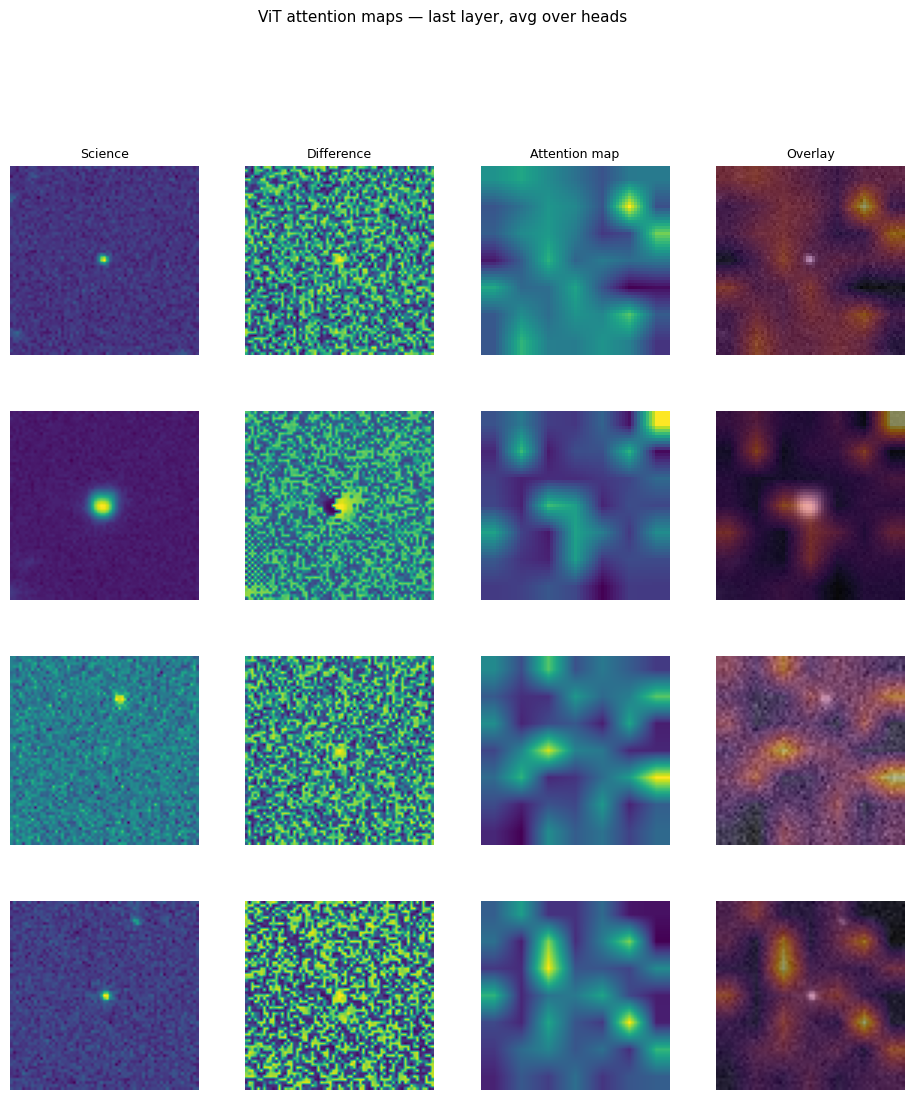

In [14]:
vit_model.eval()
x_batch, y_batch = next(iter(st_val))
n_grid = IMG_SIZE // PATCH_SIZE   # 7

with torch.no_grad():
    _, attn_list = vit_model(x_batch.to(device), return_attn=True)

# Last-layer [CLS] attention to all patches; average over heads → reshape to grid
cls_attn = attn_list[-1][:, :, 0, 1:].mean(dim=1).cpu().numpy()   # (B, N_patches)
attn_map = cls_attn.reshape(-1, n_grid, n_grid)                     # (B, 7, 7)

# Upsample attention map to stamp resolution for overlay
import torch.nn.functional as F
attn_up = F.interpolate(
    torch.tensor(attn_map).unsqueeze(1).float(),
    size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False
).squeeze(1).numpy()   # (B, 63, 63)

fig, axes = plt.subplots(4, 4, figsize=(12, 12),
                          gridspec_kw={"wspace": 0.05, "hspace": 0.3})
n_show = min(4, len(x_batch))
for i in range(n_show):
    science = np.arcsinh(x_batch[i, 0].numpy())   # science channel
    vmin, vmax = science.min(), science.max()
    for col, (img, title) in enumerate([
        (science,                          "Science"),
        (np.arcsinh(x_batch[i, 2].numpy()), "Difference"),
        (attn_up[i],                       "Attention map"),
        (science,                          "Overlay"),
    ]):
        ax = axes[i, col]
        if col < 3:
            ax.imshow(img, cmap="viridis", origin="lower")
        else:
            ax.imshow(science,    cmap="gray",   origin="lower", alpha=1.0)
            ax.imshow(attn_up[i], cmap="inferno", origin="lower", alpha=0.5)
        ax.axis("off")
        if i == 0: ax.set_title(title, fontsize=9)
        if col == 0: ax.set_ylabel(ST_CLASSES[y_batch[i]], fontsize=9,
                                    rotation=0, labelpad=40, va="center")

fig.suptitle("ViT attention maps — last layer, avg over heads", fontsize=11, y=1.01)
plt.show()

## Assumptions, caveats, and how to take this further
This is a deliberately small, toy example. ~310 light curves across 4 classes and ~286 stamps, so everything trains while you watch, not to beat a benchmark. The method is the point; the numbers are not.

What we assumed (and what it costs):

- Light-curve interpolation. ZTF sampling is irregular, so we linearly interpolated each object onto a regular 3-day grid (T = 60, from −30 to +150 d after first detection). This fabricates values in the gaps between sparse detections. The binary mask channel flags real vs. filled steps — that's how we (and the model) stay honest about it. An alternative is feeding time itself as a feature with padding + attention masking; we chose interpolation because it's simpler to teach.
- Fixed window. Anything before −30 d or after +150 d is dropped. Slow or very early/late events are truncated.
- Normalization from training only. Per-band flux stats and per-channel stamp stats are computed on the train split and applied unchanged to val/test — no leakage.
- arcsinh on stamps to compress the dynamic range while keeping sign.
- Small models by design (d_model=64, 4 heads, 2 layers). With data this small, a CNN/RNN (or even gradient-boosted features) is a completely fair, often better, baseline. The Bitter Lesson cuts both ways: a weak inductive bias only pays off once you feed it data and compute.
- Cost. Attention is O(T²). Harmless at T=60 or 49 patches; it becomes the bottleneck at survey scale.

## How to apply this to your own science:

- Pick your tokens: decide what one element is (a time step, a patch, a spectral bin, a detection…).
- Pick your taxonomy: swap in your own classes; nothing here is ZTF-specific.
- Bridge modalities: fuse the light-curve [CLS] and the stamp [CLS] (late fusion), or feed both token streams to one shared encoder. You can change the tokenizer, keep the engine.

### Homework:

In the tutorial we queried ALeRCE with **fixed** choices (4 light-curve classes, 3 stamp
classes, one probability threshold, one interpolation grid). Your homework is to turn that
into a reusable **Claude Code skill** so you can build *your own* datasets just by describing
them in plain language — for example *"200 RR Lyrae and Cepheid light curves"* or
*"150 SN and AGN stamps"*. That skill is the "agent tool" from the abstract: it wraps the
classical ALeRCE client so an agent can call it.

## How to use this

1. Open this repo in Claude Code (the tutorial code is the reference).
2. Paste the prompt below.
3. Claude will read the existing query code, propose a plan, and (after you approve) build
   the skill. Then ask it for a dataset and watch it run the tool.

> Requires network access to hit the live ALeRCE API. `pip install alerce`.

## Reference: valid class names

- **`stamp_classifier`** (5): `AGN`, `SN`, `VS`, `asteroid`, `bogus`
- **`lc_classifier`** (15, hierarchical):
  - *transient*: `SNIa`, `SNIbc`, `SNII`, `SLSN`
  - *stochastic*: `QSO`, `AGN`, `Blazar`, `YSO`, `CV/Nova`
  - *periodic*: `LPV`, `E`, `DSCT`, `RRL`, `CEP`, `Periodic-Other`
- Client docs: https://alerce.readthedocs.io/en/latest/

---

## The prompt (copy everything below)

```
Create a Claude Code skill called `alerce-dataset-builder` that turns the ALeRCE broker's
Python client into a reusable tool for building ML-ready datasets from ZTF data. The skill
should let me describe a dataset in plain language and produce a saved .npz file ready for
training — e.g. "200 RR Lyrae and Cepheid light curves" or "150 SN and AGN stamps".

CONTEXT — read these first, then generalize them:
- A working but HARD-CODED version of these queries already exists in this repo:
  `transformers_tutorial.ipynb` (Part 1) and `utils/lc_preprocessing.py`. Read both before
  writing anything. Your job is to turn every hard-coded constant (classes, objects per class,
  probability threshold, minimum detections, interpolation grid) into a parameter.
- ALeRCE client: `pip install alerce`; `from alerce.core import Alerce; client = Alerce()`.
  Docs: https://alerce.readthedocs.io/en/latest/

TWO DATASET TYPES TO SUPPORT:

1) Image stamps (classifier = "stamp_classifier"):
   - Query per class with client.query_objects(classifier="stamp_classifier",
     class_name=..., probability=<min_prob>, ranking=1, order_by="probability",
     order_mode="DESC", count=False, page_size=<n>, format="pandas").
   - For each object, take the first detection that has_stamp, get its candid, and call
     client.get_stamps(oid, candid) to get the (science, reference, difference) triplet.
   - Skip any object whose cutout is not the expected square size (older alerts sometimes
     differ). Stack kept stamps to (N, 3, H, W) float32.

2) Multi-band light curves (classifier = "lc_classifier"):
   - IMPORTANT API DIFFERENCE: lc_classifier does NOT accept `probability`, `ranking`, or
     `count` as server-side filters — passing them returns HTTP 403. Query with only
     order_by="probability", order_mode="DESC", page_size=<n>, and filter by probability
     CLIENT-SIDE after the query.
   - For each object, download detections (query_detections) and non-detections
     (query_non_detections). Non-detections can return 403 for some objects — catch THAT
     specific case and continue with detections only; never let it abort the object.
   - Require a minimum number of detections per band before keeping an object.
   - Default output: interpolate each curve onto a regular time grid (parameters: days before
     first detection, days after, step in days), returning fluxes (N, T, bands),
     masks (N, T, bands) marking real vs interpolated steps, and a shared times (T,). Base the
     interpolation on utils/lc_preprocessing.py but make the whole grid parameterized.
   - Also support a `raw` mode that keeps the original irregular detections instead of
     interpolating (save as an object array of variable-length curves).

OUTPUT FORMAT — must match the tutorial exactly so datasets are drop-in for training:
- stamps.npz keys: stamps (N,3,H,W), labels (N,), oids (N,), class_names.
- lightcurves.npz keys: fluxes (N,T,bands), masks (N,T,bands), labels (N,), oids (N,),
  times (T,), class_names.

PARAMETERS the skill must expose (CLI args or a small config) — NO silent defaults for
anything that changes the dataset:
- dataset type (stamps | lightcurves)
- list of class names
- objects per class
- minimum classification probability
- (light curves) minimum detections per band; interpolation grid (min_time, eval_date, step);
  raw vs interpolated
- output path
- random seed

CODE QUALITY & RESEARCH INTEGRITY:
- Fail loud. Validate inputs and raise clear errors on missing required parameters or empty
  query results. No bare `except:` — catch only the specific exceptions you expect (e.g. the
  non-detection 403). Never silently drop an object without logging which oid and why.
- Log the full query configuration and a per-class summary of how many objects were actually
  kept vs requested.
- Type hints and short docstrings. Use pathlib.Path. Use the logging module, not bare prints.

DELIVERABLES:
- A SKILL.md (front matter + description) written so that when I ask for "a dataset of N
  <classes> <stamps|light curves>", Claude knows to invoke this skill.
- A self-contained Python script/module that does the querying, building, and saving.
- A short usage section with 2–3 example invocations, including one stamps example and one
  light-curve example with a NON-default interpolation grid.
- A validation step that reloads the saved .npz, asserts the shapes, and prints per-class
  counts, so I can confirm the dataset before training.

PROCESS:
- First read transformers_tutorial.ipynb (Part 1) and utils/lc_preprocessing.py, then briefly
  describe your plan (skill structure, parameters, the two builder functions) and confirm the
  .npz schema. Wait for my approval before implementing.
- Keep queries gentle (reasonable page sizes). Remind me that hitting the live API needs
  network access.
```

---

## What "done" looks like

A good submission lets you run something like:

> *"Use alerce-dataset-builder to make 100 QSO and Blazar light curves on a 2-day grid from
> −20 to +120 days, probability ≥ 0.7, and save to `dataset/agn_lc.npz`."*

…and Claude invokes the skill, queries ALeRCE, builds the file, and prints the per-class
counts — a dataset that loads directly into the `make_lc_loaders` / `make_stamp_loaders`
functions from the tutorial.

## Stretch goals

- Add a `taxonomy` dataset type that pulls *all* classes under a hierarchy node (e.g. all
  *periodic* classes) in one call.
- Add a multimodal mode: for each object, fetch **both** the light curve and the stamp, so you
  can try fusing the two `[CLS]` tokens (the natural next model after this tutorial).
- Cache raw API responses so re-builds with different grids don't re-query.
